# Bank Customer Churn KDD — Phase 5

## Visualization & Knowledge Presentation

**Owner:** Insight Communicator  
**Purpose:** provide a reproducible handoff from the four analytical phases to the interactive Dash dashboard, the written report, and the 10-minute presentation. This notebook checks evidence traceability and answers the central discovery question explicitly; the interactive deliverable itself lives in `visualization/`.

In [1]:
from pathlib import Path
import sys
import timeit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / 'data' / 'raw' / 'churn.csv').is_file()
     and (candidate / 'visualization' / 'app.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Open this notebook from inside the Project_DATAMINING repository.')

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
CLUSTERED_PATH = PROCESSED_DIR / 'churn_clustered.csv'
TOP_RULES_PATH = OUTPUTS_DIR / 'ph3_top_association_rules.csv'
ANOMALY_PATH = OUTPUTS_DIR / 'ph4_anomaly_report.csv'
METRICS_PATH = OUTPUTS_DIR / 'evaluation_metrics.csv'

required = [CLUSTERED_PATH, TOP_RULES_PATH, ANOMALY_PATH, METRICS_PATH]
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError('Run Phases 1–4 first. Missing:\n' + '\n'.join(map(str, missing)))

clustered = pd.read_csv(CLUSTERED_PATH)
top_rules = pd.read_csv(TOP_RULES_PATH)
anomalies = pd.read_csv(ANOMALY_PATH)
metrics = pd.read_csv(METRICS_PATH)
print(f'Loaded {len(clustered):,} clustered rows, {len(top_rules)} documented rules, '
      f'and {len(anomalies):,} anomaly-report rows.')

Loaded 10,000 clustered rows, 10 documented rules, and 10,000 anomaly-report rows.


In [2]:
# ── Deliverable and traceability gate ────────────────────────────────────
dashboard_files = [
    PROJECT_ROOT / 'visualization' / 'app.py',
    PROJECT_ROOT / 'visualization' / 'prepare_data.py',
    PROJECT_ROOT / 'visualization' / 'figures.py',
    PROJECT_ROOT / 'visualization' / 'assets' / 'styles.css',
]
qa_rows = [
    ('Interactive Dash application present', all(path.is_file() for path in dashboard_files)),
    ('All 10,000 rows reach cluster output', len(clustered) == 10000),
    ('At least 10 interpreted rules exported', len(top_rules) >= 10 and 'Business Commentary' in top_rules),
    ('Anomaly rows have stable source key', 'Source_RowNumber' in anomalies),
    ('Every flagged anomaly has evidence/action',
     anomalies.loc[anomalies['Composite_Anomaly_Score'] >= 1,
                   ['Anomaly_Class', 'Anomaly_Evidence', 'Recommended_Action']].notna().all().all()),
    ('Appendix metric ledger covers Phases 1–4', set(metrics['Phase']) >= {'Phase 1', 'Phase 2', 'Phase 3', 'Phase 4'}),
]
deliverable_gate = pd.DataFrame(qa_rows, columns=['QA Check', 'Pass'])
display(deliverable_gate)
if not deliverable_gate['Pass'].all():
    raise AssertionError('Phase 5 handoff gate failed; inspect the table above.')

,QA Check,Pass
0,Interactive Dash application present,True
1,"All 10,000 rows reach cluster output",True
2,At least 10 interpreted rules exported,True
3,Anomaly rows have stable source key,True
4,Every flagged anomaly has evidence/action,True
5,Appendix metric ledger covers Phases 1–4,True


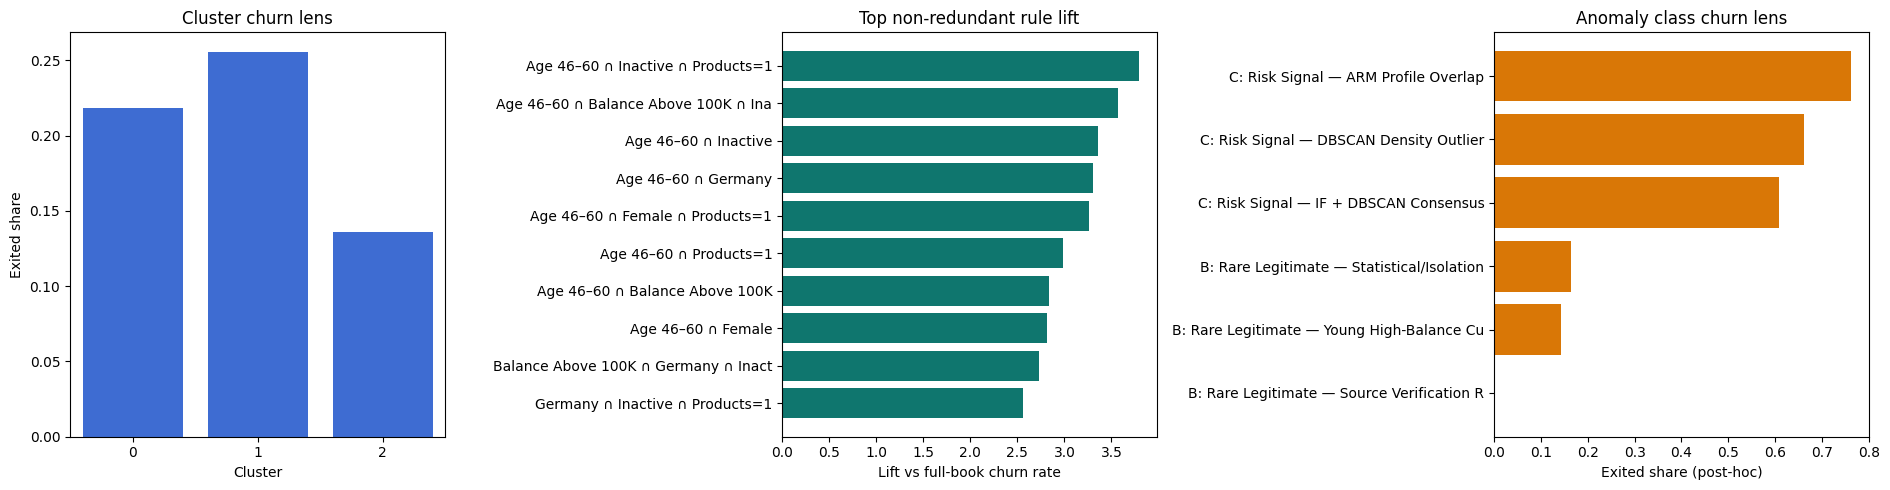

,Cluster,Cluster_Name,Customers,Churn_Lens,Churn Lens (%)
0,0,High-Balance Multi-Product Germany-Enriched Mi...,2169,0.218073,21.807284
1,1,High-Balance Single-Product Germany-Enriched W...,4168,0.255758,25.575816
2,2,Zero-Balance Multi-Product Spain-Enriched Loya...,3663,0.135954,13.595414


,IF (Conditions),Support (%),Confidence (%),Lift,Business Commentary
0,Age 46–60 ∩ Inactive ∩ Products=1,4.05,77.3,3.794,The strongest compound association has 77.3% c...
1,Age 46–60 ∩ Balance Above 100K ∩ Inactive,3.13,72.6,3.565,Association concentrates among the dataset’s a...
2,Age 46–60 ∩ Inactive,5.38,68.4,3.356,Association concentrates among the dataset’s a...
3,Age 46–60 ∩ Germany,3.38,67.3,3.305,Association concentrates among the dataset’s a...
4,Age 46–60 ∩ Female ∩ Products=1,3.23,66.5,3.263,"Among women aged 46–60 with one product, churn..."
5,Age 46–60 ∩ Products=1,6.06,60.9,2.990,Association concentrates among the dataset’s a...
6,Age 46–60 ∩ Balance Above 100K,4.89,57.7,2.834,Association concentrates among the dataset’s a...
7,Age 46–60 ∩ Female,4.71,57.3,2.813,Association concentrates among the dataset’s a...
8,Balance Above 100K ∩ Germany ∩ Inactive ∩ Prod...,3.27,55.7,2.735,Association concentrates among inactive custom...
9,Germany ∩ Inactive ∩ Products=1,3.75,52.1,2.557,The assigned Germany hypothesis is supported: ...


In [3]:
# ── Evidence-backed visual handoff ───────────────────────────────────────
cluster_summary = (clustered.groupby(['Cluster', 'Cluster_Name'])
                   .agg(Customers=('Exited', 'size'), Churn_Lens=('Exited', 'mean'))
                   .reset_index())
class_summary = (anomalies[anomalies['Composite_Anomaly_Score'] >= 1]
                 .groupby('Anomaly_Class')
                 .agg(Records=('Exited', 'size'), Churn_Lens=('Exited', 'mean'))
                 .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.barplot(data=cluster_summary, x='Cluster', y='Churn_Lens', ax=axes[0], color='#2563eb')
axes[0].set_title('Cluster churn lens')
axes[0].set_ylabel('Exited share')

rule_plot = top_rules.nlargest(10, 'Lift').sort_values('Lift')
axes[1].barh(rule_plot['IF (Conditions)'].str.slice(0, 36), rule_plot['Lift'], color='#0f766e')
axes[1].set_title('Top non-redundant rule lift')
axes[1].set_xlabel('Lift vs full-book churn rate')

class_plot = class_summary.sort_values('Churn_Lens')
axes[2].barh(class_plot['Anomaly_Class'].str.slice(0, 42), class_plot['Churn_Lens'], color='#d97706')
axes[2].set_title('Anomaly class churn lens')
axes[2].set_xlabel('Exited share (post-hoc)')
plt.tight_layout()
plt.show()

display(cluster_summary.assign(**{'Churn Lens (%)': cluster_summary['Churn_Lens'] * 100}))
display(top_rules[['IF (Conditions)', 'Support (%)', 'Confidence (%)', 'Lift', 'Business Commentary']])

In [4]:
# ── Representative in-memory interaction benchmark ─────────────────────
# This times the data operations behind common filters. It is evidence about
# server-side responsiveness, not a substitute for browser/network profiling.
def representative_interaction():
    _ = clustered.loc[clustered['Cluster'] == 1, ['Age', 'Balance', 'Exited']]
    _ = top_rules.nlargest(5, 'Lift')
    _ = anomalies.loc[anomalies['Anomaly_Class'].str.startswith('C')]

per_call_ms = np.array(timeit.repeat(
    'representative_interaction()', globals=globals(), number=100, repeat=7
)) / 100 * 1000
interaction_benchmark = pd.DataFrame({
    'Statistic': ['median', 'p95 approximation', 'maximum'],
    'Server-side filter time (ms)': [
        np.median(per_call_ms), np.quantile(per_call_ms, 0.95), per_call_ms.max()
    ],
})
display(interaction_benchmark.round(3))
print('Rubric threshold status for this server-side test:',
      'PASS' if per_call_ms.max() < 100 else 'REVIEW')
print('Approved evidence scope: server-side benchmark plus a localhost demo; '
      'the docent confirmed separate browser-latency measurement is not required.')

,Statistic,Server-side filter time (ms)
0,median,3.554
1,p95 approximation,3.619
2,maximum,3.623


Rubric threshold status for this server-side test: PASS
Approved evidence scope: server-side benchmark plus a localhost demo; the docent confirmed separate browser-latency measurement is not required.


## Central question — what did we discover that was not already obvious from the raw data?

The raw table shows individual attributes and a churn label. The KDD pipeline reveals three higher-order relationships:

1. **Engagement conditions interact.** The age 46–60 band becomes much more churn-associated when combined with inactivity and shallow product depth; non-redundancy checks show which added conditions genuinely improve confidence over simpler rules.
2. **Balance/product behaviour supports stable operational personas despite weak natural separation.** K-Means K=3 and Ward have strong membership agreement, but the low silhouette is disclosed: the personas segment a continuum rather than prove three isolated customer species.
3. **The most churn-aligned anomalies are unusual combinations, not merely extreme single values.** Isolation Forest and DBSCAN converge on structural profiles that IQR/Z-score often miss. Record-level classes separate those review signals from plausible rarities without defining risk from `Exited` itself.

The appropriate bank response is investigation and controlled intervention testing—not an accuracy contest, causal claim, or automated adverse action.

## 10-minute presentation and Mining Expo handoff

| Time | Speaker focus | Evidence to show |
|---:|---|---|
| 0:00–1:00 | Business question + KDD framing | Why discovery, not churn prediction |
| 1:00–2:15 | Phase 1 | Cleaning audit, dual-path design, correlation + entropy |
| 2:15–4:15 | Phase 2 | Elbow vs silhouette, three algorithms, personas, ARI/cophenetic caveat |
| 4:15–6:15 | Phase 3 | Rule funnel, top non-redundant rule, action and causality caveat |
| 6:15–8:00 | Phase 4 | Method comparison, DBSCAN cross-reference, record-level typology |
| 8:00–9:15 | Central discoveries | The three findings above in plain business language |
| 9:15–10:00 | Actions + limits | Tests, safeguards, longitudinal-data need |

**Expo answers to rehearse:**

- Most surprising rules: interaction rules where inactivity/product depth materially strengthen the age-band association; explain incremental confidence, not only lift.
- Most interpretable clustering method: K-Means K=3 for personas, triangulated with Ward; state the weak silhouette honestly.
- Anomalies: structural IF/DBSCAN overlap is the main review signal; univariate extremes are often rare legitimate cases.
- Cross-group contrast: this project discovers disengagement/relationship patterns; fraud or credit-approval projects investigate different behaviours and should not share the same business interpretation.
- Sudden balance drops: this is a one-row-per-customer snapshot with no balance history or closure timestamps, so a *drop* is unobservable in principle. Phase 4 therefore reports the retrospective high-value-exit subset as descriptive evidence, not a fabricated sequence. A real early-warning test requires longitudinal balances and event dates.

Run the dashboard from `visualization/` with `python prepare_data.py` and then `python app.py`. Rebuild the cache after rerunning any analytical phase. The docent approved this localhost demo format; click through the cluster, rule-network, and anomaly views before presenting.

In [5]:
# Appendix-ready metric ledger: one traceable source for report/presentation numbers.
display(metrics)
print(f'Metric ledger: {METRICS_PATH}')

,Phase,Metric,Value,Unit,Definition,Source
0,Phase 1,Clustering distance features,8.000000,features,Financial/behavioral features in the Euclidean...,phase1_preprocessing.ipynb
1,Phase 1,Continuous variables binned,5.000000,variables,"CreditScore, Age, Tenure, Balance, and Estimat...",phase1_preprocessing.ipynb
2,Phase 1,Domain-range violations,0.000000,checks,Range or integer-type violations under the doc...,phase1_preprocessing.ipynb
3,Phase 1,Duplicate rows,0.000000,records,Exact duplicate raw rows.,phase1_preprocessing.ipynb
4,Phase 1,Missing values,0.000000,cells,Null cells before preprocessing.,phase1_preprocessing.ipynb
5,Phase 1,Raw rows audited,10000.000000,records,Rows read from the raw Kaggle snapshot.,phase1_preprocessing.ipynb
6,Phase 2,Adjusted Rand Index (K-Means vs Ward),0.746106,score,Full-data partition agreement adjusted for cha...,phase2_clustering.ipynb
7,Phase 2,Cophenetic correlation (Ward),0.394356,correlation,"Ward tree on deterministic n=2,000 diagnostic ...",phase2_clustering.ipynb
8,Phase 2,DBSCAN epsilon,1.250000,standardized distance,Tested value nearest the 10-NN distance knee (...,phase2_clustering.ipynb
9,Phase 2,DBSCAN noise records,554.000000,records,Full-data density-noise records passed to Phas...,phase2_clustering.ipynb


Metric ledger: C:\Users\Thomas\Documents\Project_DATAMINING\outputs\evaluation_metrics.csv
